# SmartShrimp: Genetic Algorithm Based Feeding Optimization

SmartShrimp is a smart agriculture/aquaculture project that applies a Genetic Algorithm (GA) to shrimp feeding optimization.

The objective is to optimize a short feeding schedule so shrimp growth improves while feed cost and feed waste are reduced. The notebook acts as the explanation, data analysis, preprocessing, visualization, simulation, and interpretation file. The GA implementation is kept separately in `ga_feeding_optimizer.py`.

## 1. Project Title and Overview

**Project title:** SmartShrimp (A Genetic Algorithm-Based Feeding Optimization)

Shrimp farming is part of smart agriculture and aquaculture because farmers can use sensor data, production measurements, and AI optimization to improve daily decisions. In this project, environmental data such as temperature, pH, and dissolved oxygen are combined with shrimp growth measurements.

The goal is to find a feeding schedule that supports good average body weight (ABW), lowers unnecessary feed use, reduces feed cost, and avoids feeding too heavily when water conditions are less suitable.

## 2. Problem Definition

Many shrimp farms use fixed feeding schedules where the same feed amount is given every day. This is simple, but it may ignore important changes in water quality and shrimp growth condition.

Too little feed can slow growth. Too much feed can increase cost, leave waste in the pond, and worsen water quality. Optimized feeding is useful because it searches for a balanced schedule instead of assuming one fixed amount is always best.

This project uses a Genetic Algorithm as the AI optimization technique. The GA tests many feeding schedules, scores them with a fitness function, and improves the population through selection, crossover, mutation, and elitism.

## Short-Term Optimization and Repeat-Over-Time 

The 7-day schedule represents a short-term feeding optimization window, not the full shrimp grow-out cycle. In actual aquaculture, feeding decisions may be adjusted daily or weekly. Therefore, this 7-day GA schedule can be repeatedly applied across the grow-out period as new water-quality and shrimp-growth data become available.

Although shrimp culture usually requires several months before marketable size is reached, this study uses a 7-day optimization window to represent short-term feeding management. The purpose of the model is not to predict the full harvest period, but to optimize feeding decisions within a smaller time frame.

The Python script includes `run_weekly_optimization()` to demonstrate how the 7-day optimizer can be reused weekly with updated data.

In [1]:
# Demonstrates how the 7-day GA feeding model can be repeated as new weekly pond data becomes available.
def weekly_optimization_pseudocode(weekly_datasets):
    weekly_results = []

    for week_number, updated_week_data in enumerate(weekly_datasets, start=1):
        best_schedule, history = run_ga(updated_week_data)
        comparison = compare_with_fixed_schedule(best_schedule, updated_week_data)

        weekly_results.append({
            "week": week_number,
            "best_schedule": best_schedule,
            "comparison": comparison,
        })

    return weekly_results

print("The project script uses run_weekly_optimization() for this repeat-over-time concept.")

The project script uses run_weekly_optimization() for this repeat-over-time concept.


## 3. Dataset Loading

The project uses two datasets:

1. https://www.kaggle.com/datasets/jocelyndumlao/iot-monitoring-of-water-quality-and-tilapia 
- aquaculture IoT/environment data with temperature, pH, dissolved oxygen, date, and time fields.
2. https://www.kaggle.com/datasets/achfikri/shrimp-dataset
- shrimp measurement data with treatment group, average body weight, length, and volume.

The IoT file supplies water-condition variables. The shrimp measurement file supplies ABW values used as the baseline and target for the optimization model.

In [2]:
# Import the clean GA implementation used for shrimp feeding optimization and result analysis.
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from ga_feeding_optimizer import (
    CHROMOSOME_LENGTH,
    FEED_COST_PER_GRAM,
    FIXED_FEED_AMOUNT,
    IOT_DATA_PATH,
    MEASUREMENT_DATA_PATH,
    OUTPUT_DIR,
    compare_with_fixed_schedule,
    fitness_function,
    load_data,
    plot_results,
    plot_rolling_window_results,
    run_ga,
    run_rolling_window_analysis,
    run_weekly_optimization,
    summarize_rolling_window_results,
    simulate_schedule,
)

plt.style.use("seaborn-v0_8-whitegrid")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

In [3]:
raw_iot_data = pd.read_excel(IOT_DATA_PATH)
measurement_data = pd.read_csv(MEASUREMENT_DATA_PATH)

print("IoT dataset shape:", raw_iot_data.shape)
print("Shrimp measurement dataset shape:", measurement_data.shape)
display(raw_iot_data.head())
display(measurement_data.head())

IoT dataset shape: (4383, 28)
Shrimp measurement dataset shape: (548, 4)


,Datetime,Month,Average Fish Weight (g),Survival Rate (%),Disease Occurrence (Cases),Temperature (°C),Dissolved Oxygen (mg/L),pH,Turbidity (NTU),Month_Num,...,day,hour,oxigeno_scaled,ph,turbidez,Oxygenation Automatic,Corrective Measures,Thermal Risk Index,Low Oxygen Alert,Health Status
0,2024-01-01 00:00:00,January,275.82,95.27,2.0,27.47,6.34,7.98,3.3,1.0,...,1.0,0.0,8.355273,0.387898,0.020505,Yes,No,Normal,Safe,Stable
1,2024-01-01 01:00:00,January,275.82,95.27,2.0,27.47,6.34,7.98,3.3,1.0,...,1.0,1.0,8.256397,0.343950,0.108561,No,No,Normal,Safe,Stable
2,2024-01-01 02:00:00,January,275.82,95.27,2.0,27.47,6.34,7.98,3.3,1.0,...,1.0,2.0,8.511549,0.365285,0.410457,Yes,No,Normal,Safe,Stable
3,2024-01-01 03:00:00,January,275.82,95.27,2.0,27.47,6.34,7.98,3.3,1.0,...,1.0,3.0,8.362301,0.189601,0.891217,No,No,Normal,Safe,Stable
4,2024-01-01 04:00:00,January,275.82,95.27,2.0,27.47,6.34,7.98,3.3,1.0,...,1.0,4.0,8.003350,0.318775,0.936614,Yes,No,Normal,Safe,Stable


,treatment,average_body_weight,length_cm,volume_ml
0,With Treatment,24.731928,11.040681,70.082605
1,With Treatment,21.239546,14.216628,59.356163
2,With Treatment,25.562287,13.637931,66.952488
3,With Treatment,30.376664,11.879523,64.287550
4,With Treatment,20.712156,13.353565,78.845603


## 4. Data Preprocessing

Preprocessing prepares the raw files for the GA model.

Steps used here:

- Check missing values in both datasets.
- Convert the IoT timestamp into daily records.
- Keep the required variables: day, temperature, pH, dissolved oxygen, fixed feed amount, ABW baseline, and ABW target.
- Fill missing numerical values with median values when needed.
- Create an environmental score from temperature, pH, and dissolved oxygen.
- Create scaled numerical columns for easier analysis and visualization.

In [4]:
print("Missing values in IoT dataset:")
display(raw_iot_data.isna().sum().sort_values(ascending=False).head(10))

print("Missing values in shrimp measurement dataset:")
display(measurement_data.isna().sum())

Missing values in IoT dataset:


Datetime                      0
Month                         0
Average Fish Weight (g)       0
Survival Rate (%)             0
Disease Occurrence (Cases)    0
Temperature (°C)              0
Dissolved Oxygen (mg/L)       0
pH                            0
Turbidity (NTU)               0
Month_Num                     0
dtype: int64

Missing values in shrimp measurement dataset:


treatment              0
average_body_weight    0
length_cm              0
volume_ml              0
dtype: int64

In [5]:
# load_data() combines IoT water-quality readings with shrimp ABW measurements for the GA.
data = load_data()

print("Prepared GA dataset:")
display(data)

scaled_data = data.copy()
for column in ["temperature", "pH", "dissolved_oxygen", "environment_score", "safe_feed_limit"]:
    minimum = scaled_data[column].min()
    maximum = scaled_data[column].max()
    scaled_data[f"{column}_scaled"] = (scaled_data[column] - minimum) / (maximum - minimum)

print("Scaled numerical features used for analysis:")
display(scaled_data[["day", "temperature_scaled", "pH_scaled", "dissolved_oxygen_scaled", "environment_score_scaled"]])

Prepared GA dataset:


,day,date,temperature,pH,dissolved_oxygen,environment_score,safe_feed_limit,fixed_feed,baseline_abw,target_abw
0,1,2024-06-25,27.45,7.88,7.72,0.915,166.125,150.0,19.932469,21.925715
1,2,2024-06-26,27.45,7.88,7.72,0.915,166.125,150.0,19.932469,21.925715
2,3,2024-06-27,27.45,7.88,7.72,0.915,166.125,150.0,19.932469,21.925715
3,4,2024-06-28,27.45,7.88,7.72,0.915,166.125,150.0,19.932469,21.925715
4,5,2024-06-29,27.45,7.88,7.72,0.915,166.125,150.0,19.932469,21.925715
5,6,2024-06-30,27.45,7.88,7.72,0.915,166.125,150.0,19.932469,21.925715
6,7,2024-07-01,27.45,7.88,7.72,0.915,166.125,150.0,19.932469,21.925715


Scaled numerical features used for analysis:


,day,temperature_scaled,pH_scaled,dissolved_oxygen_scaled,environment_score_scaled
0,1,NaN,NaN,NaN,NaN
1,2,NaN,NaN,NaN,NaN
2,3,NaN,NaN,NaN,NaN
3,4,NaN,NaN,NaN,NaN
4,5,NaN,NaN,NaN,NaN
5,6,NaN,NaN,NaN,NaN
6,7,NaN,NaN,NaN,NaN


## 5. Exploratory Data Analysis (EDA)

EDA helps explain the production context before optimization. The charts below summarize shrimp ABW, water conditions, and feeding-related trends.

In [6]:
print("Shrimp measurement summary statistics:")
display(measurement_data.describe(include="all"))

print("Prepared environment summary statistics:")
display(data[["temperature", "pH", "dissolved_oxygen", "environment_score", "safe_feed_limit"]].describe())

Shrimp measurement summary statistics:


,treatment,average_body_weight,length_cm,volume_ml
count,548,548.000000,548.000000,548.000000
unique,2,NaN,NaN,NaN
top,With Treatment,NaN,NaN,NaN
freq,274,NaN,NaN,NaN
mean,NaN,20.929092,12.557250,63.235179
std,NaN,5.318837,2.108530,10.756103
min,NaN,3.793663,7.056711,33.031134
25%,NaN,17.328384,11.029989,55.846449
50%,NaN,20.927720,12.491442,62.948895
75%,NaN,24.123413,13.911005,70.298279


Prepared environment summary statistics:


,temperature,pH,dissolved_oxygen,environment_score,safe_feed_limit
count,7.000000e+00,7.000000e+00,7.00,7.000000e+00,7.000
mean,2.745000e+01,7.880000e+00,7.72,9.150000e-01,166.125
std,3.837369e-15,9.593423e-16,0.00,1.199178e-16,0.000
min,2.745000e+01,7.880000e+00,7.72,9.150000e-01,166.125
25%,2.745000e+01,7.880000e+00,7.72,9.150000e-01,166.125
50%,2.745000e+01,7.880000e+00,7.72,9.150000e-01,166.125
75%,2.745000e+01,7.880000e+00,7.72,9.150000e-01,166.125
max,2.745000e+01,7.880000e+00,7.72,9.150000e-01,166.125


,treatment,average_abw_g,average_length_cm,average_volume_ml
0,No Treatment,19.932469,11.959285,60.223980
1,With Treatment,21.925715,13.155214,66.246378


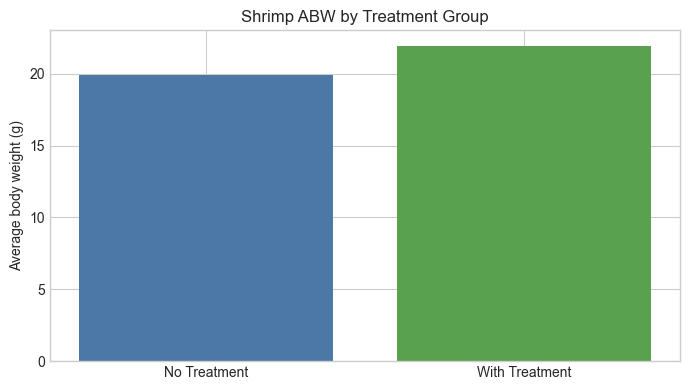

In [7]:
# Summarize ABW, length, and volume by treatment group to define the growth context.
treatment_summary = (
    measurement_data.assign(
        treatment=measurement_data["treatment"].astype(str).str.strip()
    )
    .groupby("treatment", as_index=False)
    .agg(
        average_abw_g=("average_body_weight", "mean"),
        average_length_cm=("length_cm", "mean"),
        average_volume_ml=("volume_ml", "mean"),
    )
)

display(treatment_summary)

plt.figure(figsize=(7, 4))
plt.bar(treatment_summary["treatment"], treatment_summary["average_abw_g"], color=["#4c78a8", "#59a14f"])
plt.ylabel("Average body weight (g)")
plt.title("Shrimp ABW by Treatment Group")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "abw_treatment_comparison.png", dpi=160)
plt.show()

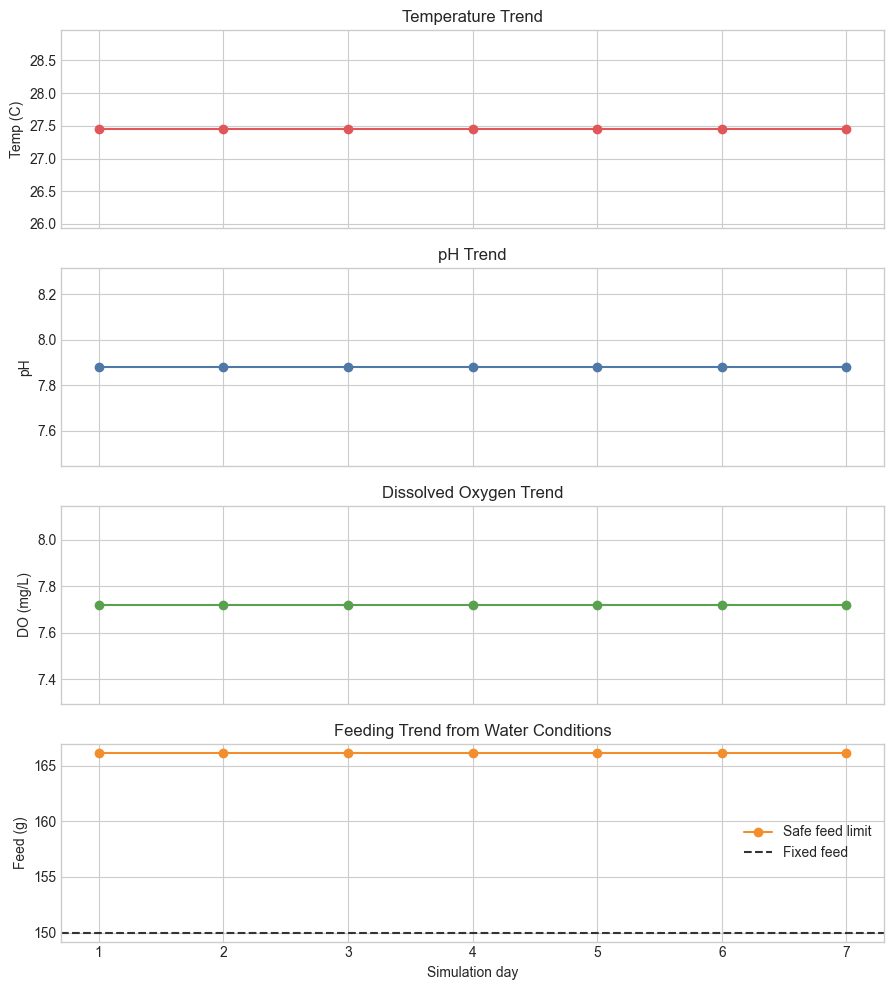

In [8]:
# Plot daily water conditions and safe_feed_limit to show how pond quality affects feeding decisions.
fig, axes = plt.subplots(4, 1, figsize=(9, 10), sharex=True)

axes[0].plot(data["day"], data["temperature"], marker="o", color="#e15759")
axes[0].set_ylabel("Temp (C)")
axes[0].set_title("Temperature Trend")

axes[1].plot(data["day"], data["pH"], marker="o", color="#4e79a7")
axes[1].set_ylabel("pH")
axes[1].set_title("pH Trend")

axes[2].plot(data["day"], data["dissolved_oxygen"], marker="o", color="#59a14f")
axes[2].set_ylabel("DO (mg/L)")
axes[2].set_title("Dissolved Oxygen Trend")

axes[3].plot(data["day"], data["safe_feed_limit"], marker="o", color="#f28e2b", label="Safe feed limit")
axes[3].axhline(FIXED_FEED_AMOUNT, color="#333333", linestyle="--", label="Fixed feed")
axes[3].set_ylabel("Feed (g)")
axes[3].set_xlabel("Simulation day")
axes[3].set_title("Feeding Trend from Water Conditions")
axes[3].legend()

plt.tight_layout()
plt.show()

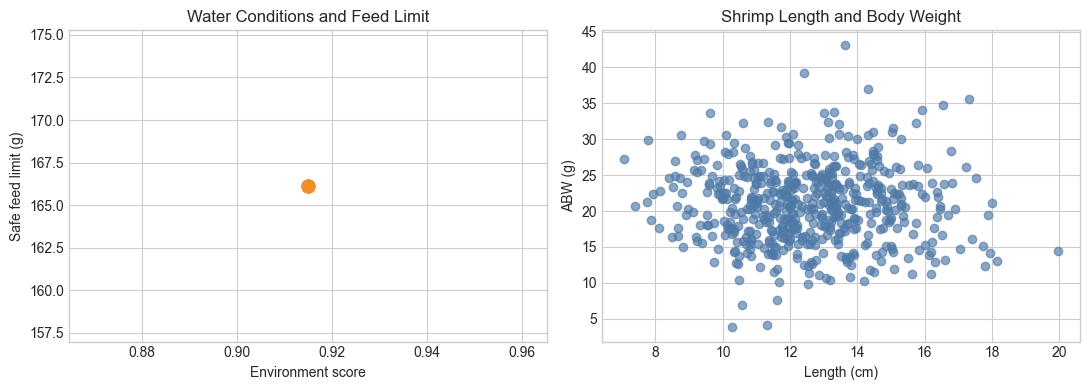

In [9]:
# environment_score is a water-quality indicator used to adjust safe feeding levels.
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].scatter(data["environment_score"], data["safe_feed_limit"], color="#f28e2b", s=80)
axes[0].set_xlabel("Environment score")
axes[0].set_ylabel("Safe feed limit (g)")
axes[0].set_title("Water Conditions and Feed Limit")

axes[1].scatter(measurement_data["length_cm"], measurement_data["average_body_weight"], alpha=0.65, color="#4e79a7")
axes[1].set_xlabel("Length (cm)")
axes[1].set_ylabel("ABW (g)")
axes[1].set_title("Shrimp Length and Body Weight")

plt.tight_layout()
plt.show()

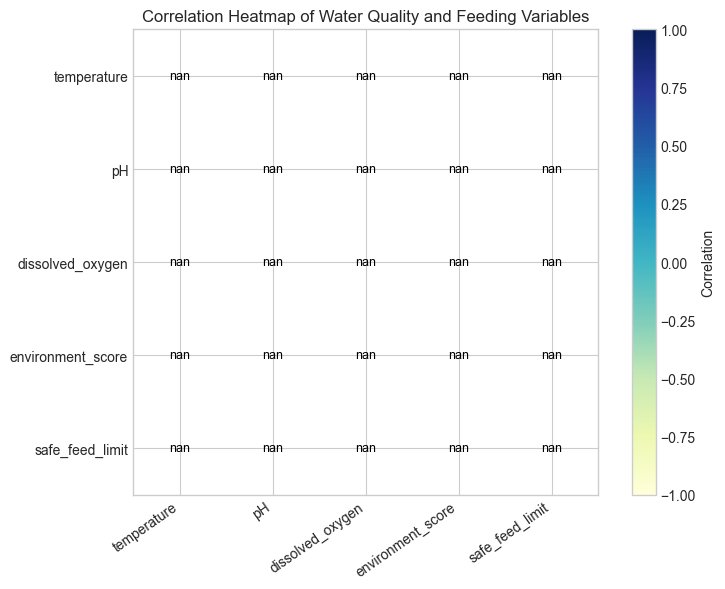

In [10]:
# Correlation heatmap shows how water-quality variables relate to feeding limits.
# SMARTSHRIMP_EXTRA_EDA: correlation heatmap
correlation_columns = [
    "temperature",
    "pH",
    "dissolved_oxygen",
    "environment_score",
    "safe_feed_limit",
]

correlation_matrix = data[correlation_columns].corr()

fig, ax = plt.subplots(figsize=(8, 6))
heatmap = ax.imshow(correlation_matrix, cmap="YlGnBu", vmin=-1, vmax=1)

ax.set_xticks(np.arange(len(correlation_columns)))
ax.set_yticks(np.arange(len(correlation_columns)))
ax.set_xticklabels(correlation_columns, rotation=35, ha="right")
ax.set_yticklabels(correlation_columns)
ax.set_title("Correlation Heatmap of Water Quality and Feeding Variables")

for row in range(len(correlation_columns)):
    for col in range(len(correlation_columns)):
        ax.text(
            col,
            row,
            f"{correlation_matrix.iloc[row, col]:.2f}",
            ha="center",
            va="center",
            color="black",
            fontsize=9,
        )

fig.colorbar(heatmap, ax=ax, label="Correlation")
plt.tight_layout()
plt.show()

The heatmap shows how the water-quality variables relate to the environmental score and safe feed limit. The GA uses `environment_score` because it combines temperature, pH, and dissolved oxygen into one simple value for deciding safer feed amounts.

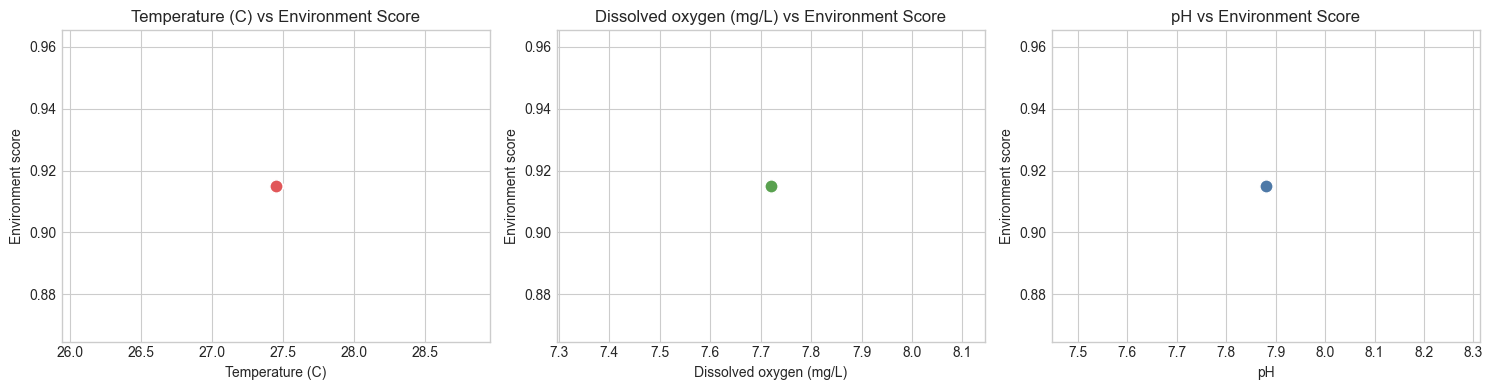

In [11]:
# These plots show how each water variable contributes to the combined environment_score.
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

scatter_settings = [
    ("temperature", "Temperature (C)", "#e15759"),
    ("dissolved_oxygen", "Dissolved oxygen (mg/L)", "#59a14f"),
    ("pH", "pH", "#4e79a7"),
]

for ax, (column, xlabel, color) in zip(axes, scatter_settings):
    ax.scatter(data[column], data["environment_score"], s=90, color=color, edgecolor="white")
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Environment score")
    ax.set_title(f"{xlabel} vs Environment Score")

plt.tight_layout()
plt.show()

These scatter plots show how each water-quality factor contributes to the environment score. Better temperature, pH, and dissolved oxygen conditions support healthier shrimp feeding and growth, so they help the GA choose feed levels more intelligently.

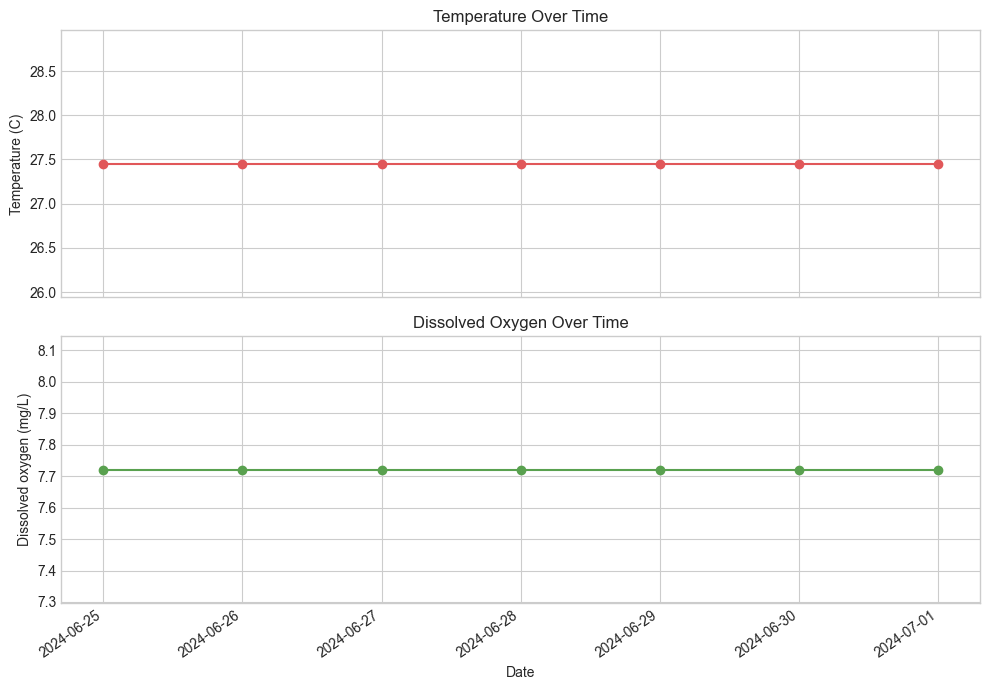

In [12]:
# Time plots support the idea that feeding should respond to changing pond conditions.
fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

axes[0].plot(data["date"], data["temperature"], marker="o", color="#e15759")
axes[0].set_title("Temperature Over Time")
axes[0].set_ylabel("Temperature (C)")

axes[1].plot(data["date"], data["dissolved_oxygen"], marker="o", color="#59a14f")
axes[1].set_title("Dissolved Oxygen Over Time")
axes[1].set_ylabel("Dissolved oxygen (mg/L)")
axes[1].set_xlabel("Date")

plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

The line plots show that water conditions can change over time, which is why a fixed feeding schedule may not always be ideal. The GA can use updated environmental data to adjust the 7-day feeding window when conditions improve or become less suitable.

## 6. Genetic Algorithm Design

**Chromosome representation:** One chromosome represents a complete 7-day feeding schedule for the short-term optimization window.

**Genes:** Each gene is the feed amount for one day. For example, a 7-day chromosome has 7 feed values.

**Fitness function:** The fitness score measures how good each feeding schedule is. A higher fitness score means the schedule is better for the project objective.

The simplified fitness idea is:

**Fitness = Growth Score - Cost Penalty - Feed Penalty - Environmental Penalty**

- **Growth Score:** based on the estimated final average body weight (ABW). A schedule gets a higher score when it supports better shrimp growth.
- **Cost Penalty:** based on feed cost, using ₱0.02775 per gram of feed. Higher feed cost reduces the fitness score.
- **Feed Penalty:** penalizes excessive feeding because overfeeding can waste feed and increase pond waste.
- **Environmental Penalty:** penalizes feeding under poor water conditions, such as less suitable temperature, pH, or dissolved oxygen.

The fitness function balances multiple objectives by maximizing shrimp growth while minimizing feed usage, cost, and environmental risk.

**Selection:** Tournament selection chooses stronger schedules as parents.

**Crossover:** Single-point crossover combines two parent schedules.

**Mutation:** Random feed changes maintain diversity and help the search escape weak local solutions.

**Elitism:** The best schedules are copied into the next generation so strong solutions are not lost.

In [13]:
# A chromosome is a 7-day feeding schedule; each gene is one day's feed amount.
print("GA configuration")
print("Chromosome length:", CHROMOSOME_LENGTH)
print("Fixed baseline feed amount:", FIXED_FEED_AMOUNT, "g/day")
print("Feed cost per gram:", FEED_COST_PER_GRAM)
print("Example fitness for fixed schedule:")
fixed_schedule = np.full(len(data), FIXED_FEED_AMOUNT)
print(round(fitness_function(fixed_schedule, data), 3))

GA configuration
Chromosome length: 7
Fixed baseline feed amount: 150.0 g/day
Feed cost per gram: 0.02775
Example fitness for fixed schedule:
1899.084


## 7. Run Simulation

The GA optimizer is run using the clean implementation in `ga_feeding_optimizer.py`. The best schedule is then compared with a traditional fixed feeding schedule.

In [14]:
# Run the GA, compare against fixed feeding, and save tables for reporting.
# The GA evolves many candidate feeding schedules over 200 generations.
best_schedule, history = run_ga(data)
# The fixed schedule is the traditional baseline for measuring improvement.
comparison = compare_with_fixed_schedule(best_schedule, data)

# The schedule table links daily feed genes to water conditions and safe feed limits.
schedule_table = data[["day", "date", "temperature", "pH", "dissolved_oxygen", "environment_score", "safe_feed_limit"]].copy()
schedule_table["safe_feed_limit"] = np.round(schedule_table["safe_feed_limit"], 2)
schedule_table["ga_optimized_feed_g"] = np.round(best_schedule, 2)
schedule_table["fixed_feed_g"] = FIXED_FEED_AMOUNT

schedule_table.to_csv(OUTPUT_DIR / "seven_day_feeding_schedule.csv", index=False)
history.to_csv(OUTPUT_DIR / "ga_history.csv", index=False)
comparison.to_csv(OUTPUT_DIR / "final_comparison_summary.csv", index=False)

print("Optimized feeding schedule:")
display(schedule_table)

print("Comparison summary:")
display(comparison)

Optimized feeding schedule:


,day,date,temperature,pH,dissolved_oxygen,environment_score,safe_feed_limit,ga_optimized_feed_g,fixed_feed_g
0,1,2024-06-25,27.45,7.88,7.72,0.915,166.12,136.17,150.0
1,2,2024-06-26,27.45,7.88,7.72,0.915,166.12,136.12,150.0
2,3,2024-06-27,27.45,7.88,7.72,0.915,166.12,136.18,150.0
3,4,2024-06-28,27.45,7.88,7.72,0.915,166.12,136.20,150.0
4,5,2024-06-29,27.45,7.88,7.72,0.915,166.12,136.16,150.0
5,6,2024-06-30,27.45,7.88,7.72,0.915,166.12,136.15,150.0
6,7,2024-07-01,27.45,7.88,7.72,0.915,166.12,136.19,150.0


Comparison summary:


,schedule,total_feed_used_g,estimated_final_abw_g,feed_cost,fitness_score,growth_target_status
0,GA Optimized Feeding,953.175196,22.366063,26.450612,1923.889889,Target Growth Achieved
1,Fixed Feeding Schedule,1050.000000,22.230464,29.137500,1899.084283,Target Growth Achieved


## 8. Results and Comparison

This section compares GA optimized feeding with the fixed feeding baseline using total feed, estimated final ABW, feed cost, fitness score, and harvest decision.

In [15]:
plot_results(best_schedule, history, data)

comparison_display = comparison.copy()
comparison_display["total_feed_used_g"] = comparison_display["total_feed_used_g"].round(2)
comparison_display["estimated_final_abw_g"] = comparison_display["estimated_final_abw_g"].round(3)
comparison_display["feed_cost"] = comparison_display["feed_cost"].round(2)
comparison_display["fitness_score"] = comparison_display["fitness_score"].round(3)
display(comparison_display)

,schedule,total_feed_used_g,estimated_final_abw_g,feed_cost,fitness_score,growth_target_status
0,GA Optimized Feeding,953.18,22.366,26.45,1923.890,Target Growth Achieved
1,Fixed Feeding Schedule,1050.00,22.230,29.14,1899.084,Target Growth Achieved


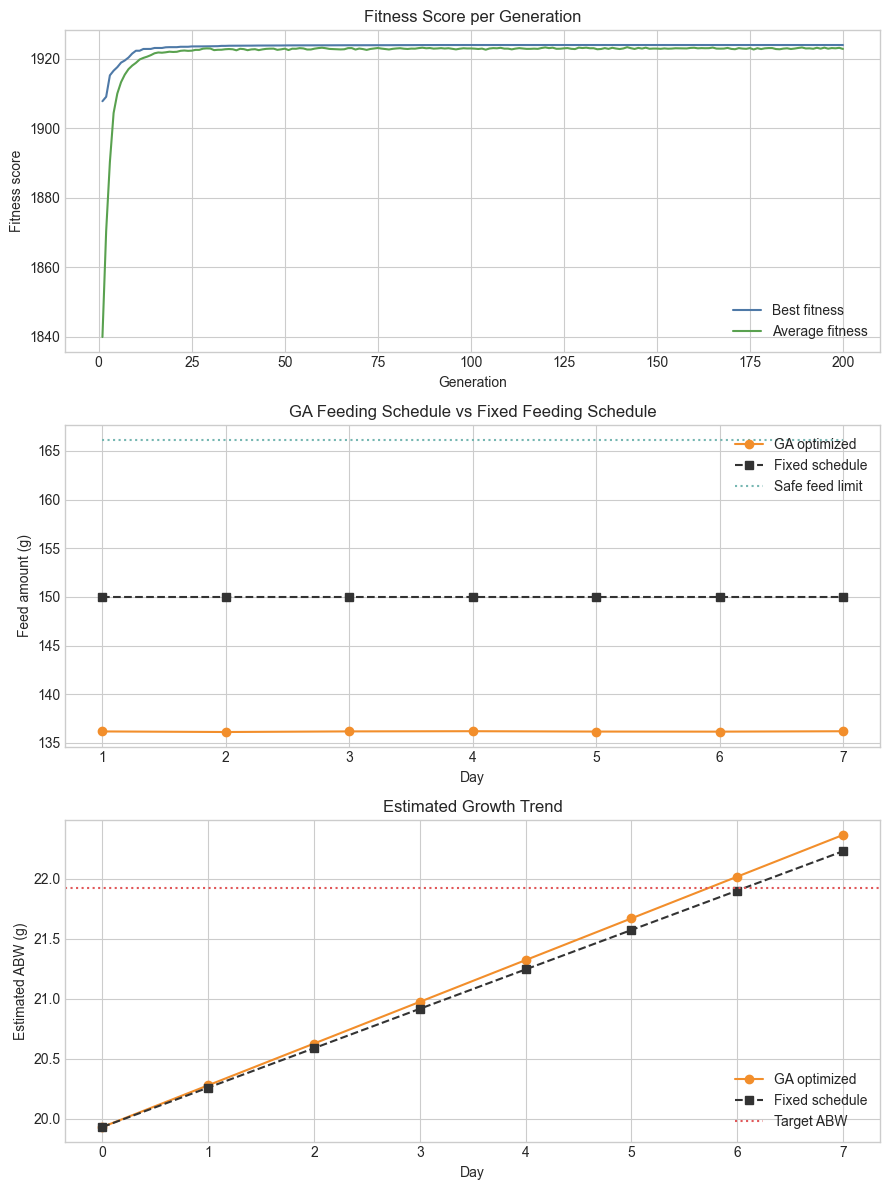

In [16]:
# Visualize GA learning, optimized feeding, and estimated ABW against the fixed baseline.
fig, axes = plt.subplots(3, 1, figsize=(9, 12))

axes[0].plot(history["generation"], history["best_fitness"], color="#4e79a7", label="Best fitness")
axes[0].plot(history["generation"], history["average_fitness"], color="#59a14f", label="Average fitness")
axes[0].set_title("Fitness Score per Generation")
axes[0].set_xlabel("Generation")
axes[0].set_ylabel("Fitness score")
axes[0].legend()

# Fixed feeding uses the same feed amount each day for comparison with GA decisions.
fixed_schedule = np.full(len(data), FIXED_FEED_AMOUNT)
axes[1].plot(data["day"], best_schedule, marker="o", color="#f28e2b", label="GA optimized")
axes[1].plot(data["day"], fixed_schedule, marker="s", color="#333333", linestyle="--", label="Fixed schedule")
axes[1].plot(data["day"], data["safe_feed_limit"], color="#76b7b2", linestyle=":", label="Safe feed limit")
axes[1].set_title("GA Feeding Schedule vs Fixed Feeding Schedule")
axes[1].set_xlabel("Day")
axes[1].set_ylabel("Feed amount (g)")
axes[1].legend()

# simulate_schedule() estimates ABW changes from feed amount and environment_score.
ga_growth = simulate_schedule(best_schedule, data)
fixed_growth = simulate_schedule(fixed_schedule, data)
growth_days = np.arange(0, len(data) + 1)
axes[2].plot(growth_days, ga_growth, marker="o", color="#f28e2b", label="GA optimized")
axes[2].plot(growth_days, fixed_growth, marker="s", color="#333333", linestyle="--", label="Fixed schedule")
axes[2].axhline(data["target_abw"].iloc[0], color="#e15759", linestyle=":", label="Target ABW")
axes[2].set_title("Estimated Growth Trend")
axes[2].set_xlabel("Day")
axes[2].set_ylabel("Estimated ABW (g)")
axes[2].legend()

plt.tight_layout()
plt.show()

In [17]:
ga_row = comparison.set_index("schedule").loc["GA Optimized Feeding"]
fixed_row = comparison.set_index("schedule").loc["Fixed Feeding Schedule"]

feed_saved = fixed_row["total_feed_used_g"] - ga_row["total_feed_used_g"]
cost_saved = fixed_row["feed_cost"] - ga_row["feed_cost"]
abw_gain = ga_row["estimated_final_abw_g"] - fixed_row["estimated_final_abw_g"]

print(f"Feed saved by GA: {feed_saved:.2f} g")
print(f"Cost saved by GA: {cost_saved:.2f} pesos")
print(f"Estimated ABW advantage of GA: {abw_gain:.3f} g")

Feed saved by GA: 96.82 g
Cost saved by GA: 2.69 pesos
Estimated ABW advantage of GA: 0.136 g


## Rolling 7-Day Window Analysis

The latest 7-day window has stable water conditions, so the optimized schedule is nearly flat. To test the optimizer more fairly, this section runs the GA across every possible consecutive 7-day window in the IoT dataset and summarizes the overall feed savings, ABW improvement, and fitness improvement.

In [18]:
rolling_results = run_rolling_window_analysis()
rolling_summary = summarize_rolling_window_results(rolling_results)

rolling_results.to_csv(OUTPUT_DIR / "rolling_window_comparison.csv", index=False)
rolling_summary.to_csv(OUTPUT_DIR / "rolling_window_summary.csv", index=False)
plot_rolling_window_results(rolling_results)

display(rolling_summary.T.rename(columns={0: "value"}))

,value
windows_tested,177
average_feed_saved_g,128.760031
median_feed_saved_g,125.946738
minimum_feed_saved_g,94.775734
maximum_feed_saved_g,180.383151
average_feed_saved_percent,12.26286
average_cost_saved,3.573091
average_abw_improvement_g,0.164646
minimum_abw_improvement_g,0.133009
maximum_abw_improvement_g,0.211493


In [19]:
rolling_display = rolling_results[
    [
        "window_number",
        "window_start",
        "window_end",
        "average_environment_score",
        "environment_score_std",
        "feed_saved_g",
        "feed_saved_percent",
        "cost_saved",
        "abw_improvement_g",
        "fitness_improvement",
        "growth_target_status",
        "ga_schedule_g",
    ]
].copy()

for column in [
    "average_environment_score",
    "environment_score_std",
    "feed_saved_g",
    "feed_saved_percent",
    "cost_saved",
    "abw_improvement_g",
    "fitness_improvement",
]:
    rolling_display[column] = rolling_display[column].round(3)

print("Top 10 windows by feed saved:")
display(rolling_display.sort_values("feed_saved_g", ascending=False).head(10))

print("Top 10 windows by ABW improvement:")
display(rolling_display.sort_values("abw_improvement_g", ascending=False).head(10))

Top 10 windows by feed saved:


,window_number,window_start,window_end,average_environment_score,environment_score_std,feed_saved_g,feed_saved_percent,cost_saved,abw_improvement_g,fitness_improvement,growth_target_status,ga_schedule_g
43,44,2024-02-13,2024-02-19,0.65,0.0,180.383,17.179,5.006,0.211,82.668,Continue Optimization,124.25;124.14;124.26;124.29;124.24;124.23;124.21
34,35,2024-02-04,2024-02-10,0.65,0.0,180.366,17.178,5.005,0.211,82.693,Continue Optimization,124.20;124.24;124.20;124.24;124.25;124.25;124.26
37,38,2024-02-07,2024-02-13,0.65,0.0,180.359,17.177,5.005,0.211,82.681,Continue Optimization,124.20;124.24;124.22;124.27;124.21;124.23;124.28
42,43,2024-02-12,2024-02-18,0.65,0.0,180.314,17.173,5.004,0.211,82.685,Continue Optimization,124.22;124.20;124.24;124.25;124.26;124.22;124.29
44,45,2024-02-14,2024-02-20,0.65,0.0,180.305,17.172,5.003,0.211,82.708,Continue Optimization,124.26;124.23;124.25;124.24;124.22;124.25;124.25
32,33,2024-02-02,2024-02-08,0.65,0.0,180.297,17.171,5.003,0.211,82.688,Continue Optimization,124.24;124.28;124.20;124.21;124.27;124.24;124.27
46,47,2024-02-16,2024-02-22,0.65,0.0,180.297,17.171,5.003,0.211,82.705,Continue Optimization,124.23;124.27;124.25;124.26;124.18;124.24;124.26
36,37,2024-02-06,2024-02-12,0.65,0.0,180.271,17.169,5.003,0.211,82.704,Continue Optimization,124.27;124.23;124.27;124.26;124.23;124.25;124.23
45,46,2024-02-15,2024-02-21,0.65,0.0,180.268,17.168,5.002,0.211,82.677,Continue Optimization,124.21;124.29;124.25;124.24;124.25;124.29;124.19
51,52,2024-02-21,2024-02-27,0.65,0.0,180.253,17.167,5.002,0.211,82.700,Continue Optimization,124.26;124.24;124.25;124.24;124.28;124.19;124.27


Top 10 windows by ABW improvement:


,window_number,window_start,window_end,average_environment_score,environment_score_std,feed_saved_g,feed_saved_percent,cost_saved,abw_improvement_g,fitness_improvement,growth_target_status,ga_schedule_g
47,48,2024-02-17,2024-02-23,0.65,0.0,180.157,17.158,4.999,0.211,82.716,Continue Optimization,124.25;124.27;124.24;124.26;124.27;124.28;124.26
33,34,2024-02-03,2024-02-09,0.65,0.0,180.180,17.160,5.000,0.211,82.724,Continue Optimization,124.24;124.26;124.26;124.26;124.27;124.26;124.27
34,35,2024-02-04,2024-02-10,0.65,0.0,180.366,17.178,5.005,0.211,82.693,Continue Optimization,124.20;124.24;124.20;124.24;124.25;124.25;124.26
35,36,2024-02-05,2024-02-11,0.65,0.0,180.110,17.153,4.998,0.211,82.696,Continue Optimization,124.28;124.24;124.31;124.25;124.25;124.28;124.28
36,37,2024-02-06,2024-02-12,0.65,0.0,180.271,17.169,5.003,0.211,82.704,Continue Optimization,124.27;124.23;124.27;124.26;124.23;124.25;124.23
37,38,2024-02-07,2024-02-13,0.65,0.0,180.359,17.177,5.005,0.211,82.681,Continue Optimization,124.20;124.24;124.22;124.27;124.21;124.23;124.28
38,39,2024-02-08,2024-02-14,0.65,0.0,180.249,17.167,5.002,0.211,82.677,Continue Optimization,124.24;124.24;124.25;124.28;124.27;124.30;124.17
39,40,2024-02-09,2024-02-15,0.65,0.0,180.228,17.165,5.001,0.211,82.716,Continue Optimization,124.25;124.26;124.24;124.27;124.24;124.28;124.24
40,41,2024-02-10,2024-02-16,0.65,0.0,180.207,17.163,5.001,0.211,82.714,Continue Optimization,124.20;124.26;124.26;124.26;124.28;124.27;124.27
41,42,2024-02-11,2024-02-17,0.65,0.0,180.239,17.166,5.002,0.211,82.719,Continue Optimization,124.26;124.25;124.24;124.25;124.24;124.27;124.26


## 9. Discussion

The GA optimized feeding schedule performs better than the fixed schedule in this simulation because it uses environmental condition scores to adjust daily feed amounts. Instead of feeding the same amount every day, it searches for a schedule that reaches the ABW target while avoiding unnecessary feed.

The rolling-window analysis strengthens this result by testing every possible consecutive 7-day window instead of relying only on the latest available week. This shows whether the GA advantage is consistent across changing water-condition periods.

The optimized schedule is better because the fitness function balances several goals at the same time: shrimp growth, feed cost, total feed use, and water-condition penalties. This makes the result more suitable for a smart aquaculture decision-support system than a fixed schedule.

Limitations:

- The growth formula is simplified for educational GA simulation.
- The ABW target is based on available shrimp measurement data rather than a full production growth curve.
- The model does not receive real-time pond sensor streams during optimization.
- More accurate feeding recommendations would require farm-specific stocking density, feed conversion ratio, mortality, biomass, and real harvest records.

## 10. Conclusion

SmartShrimp demonstrates how a Genetic Algorithm can support smarter feeding decisions in shrimp farming. The project shows the full smart agriculture/aquaculuture workflow: dataset loading, preprocessing, EDA, GA design, simulation, comparison against a fixed baseline, result visualization, and interpretation.

The final result suggests that GA-based feeding optimization can help improve shrimp growth decisions while reducing feed cost and waste, especially when combined with reliable environmental data.